In [80]:
%pip install requests
%pip install beautifulsoup4
%pip install pandas


^C
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [117]:
import requests
import time
import random
import pandas as pd
import re

from bs4 import BeautifulSoup
from urllib.parse import urljoin

In [ ]:
url = "https://www.arbeitnow.com/"
res = requests.get(url, timeout = 15)
#Die Webseite von Arbeitnow abrufen. 将arbeitnow的网页带回

res.raise_for_status()
print(res.status_code)

200


In [ ]:
with open("./test_requests.txt", "w", encoding = "utf-8") as out:
    out.write(res.text)

In [126]:
soup = BeautifulSoup(res.text, "html.parser")
jobs = soup.select("li.list-none[data-slug]")
print("Gefundene Stellenangebote：", len(jobs))


Gefundene Stellenangebote： 9


In [ ]:
first_job = jobs [0]
print(first_job.get_text(" ", strip=True))

Kundenservice Mobilfunk Inbound - Freelancer - EU, außerhalb Deutschland - 100% Remote hey contact heroes GmbH Berlin Remote Customer Service Freelance 2 days Remote Customer Service Freelance Berlin 2d


In [ ]:
#test
for link in first_job.select("a"):
    print("文字:", link.get_text(" ", strip=True),
          "web:", link.get("href"))

文字:  web: https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674
文字: Kundenservice Mobilfunk Inbound - Freelancer - EU, außerhalb Deutschland - 100% Remote web: https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674
文字: hey contact heroes GmbH web: https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh


In [ ]:
#test
for link_tag in jobs[0].find_all("a"):
    print("文字：", repr(link_tag.get_text(" ", strip=True)))
    print("链接：", link_tag.get("href"))
    print()

文字： ''
链接： https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674

文字： 'Kundenservice Mobilfunk Inbound - Freelancer - EU, außerhalb Deutschland - 100% Remote'
链接： https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674

文字： 'hey contact heroes GmbH'
链接： https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh



In [ ]:

job_list = []

for job in jobs:
    link_tags = job.select("a[href]")

    if len(link_tags) > 1:
        link_tag = link_tags[1]

        title = link_tag.get_text(" ", strip=True)
        link = urljoin(base_url, link_tag.get("href"))

        job_data = {
            "title: " : title,
            "job_url: " : link
        }
        job_list.append(job_data)
print("保存的数量: ", len(job_list))

#test
job_list[:3]


保存的数量:  50


[{'title: ': 'Kundenservice Mobilfunk Inbound - Freelancer - EU, außerhalb Deutschland - 100% Remote',
  'job_url: ': 'https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674'},
 {'title: ': 'Project Officer EC-FFPA (maternity cover)',
  'job_url: ': 'https://www.arbeitnow.com/jobs/companies/fairtrade-labelling-organizations-international-ev/project-officer-ec-ffpa-maternity-cover-bonn-452624'},
 {'title: ': 'Data Analytics, Data Science & AI Weiterbildung mit IHK-Abschluss | 100 % Remote',
  'job_url: ': 'https://www.arbeitnow.com/jobs/companies/datasmart-point-gmbh/data-analytics-data-science-ai-weiterbildung-mit-ihk-abschluss-100-remote-berlin-452130'}]

In [ ]:
#Tabelle umwandeln 转换表格
df = pd.DataFrame(job_list)

df.head()

,title:,job_url:
0,Kundenservice Mobilfunk Inbound - Freelancer -...,https://www.arbeitnow.com/jobs/companies/hey-c...
1,Project Officer EC-FFPA (maternity cover),https://www.arbeitnow.com/jobs/companies/fairt...
2,"Data Analytics, Data Science & AI Weiterbildun...",https://www.arbeitnow.com/jobs/companies/datas...
3,(Senior) IT Consultant (all genders) - Active ...,https://www.arbeitnow.com/jobs/companies/teccl...
4,Product Manager / Director – GPU & AI Services,https://www.arbeitnow.com/jobs/companies/impos...


In [ ]:
#Erste Seite speichern 保存第一页结果
df.to_csv(
    "arbeitnow_page1.csv",
    index=False,
    encoding="utf-8"
)

In [ ]:
#Listenseite analysieren: Stellentitel und URLs extrahieren
#解析列表页，得到职位名称和url

def list_page_ana(html, base_url):
    soup = BeautifulSoup(html, "html.parser")

    job_list = []

    job_cards = soup.select(
        "li.list-none[data-slug]"
    )

    for card in job_cards:
        link_tags = card.select("a[href]")

        if len(link_tags) > 1:
            link_tag = link_tags[1]

            title = link_tag.get_text(
                " ", strip = True
            )
            job_url = urljoin(base_url, link_tag.get("href"))
            job_list.append({
                "title" : title,
                "job_url" : job_url
            })
    return job_list

In [ ]:
#text clean文本清洗
def clean_text(text):
    if text is None:
        return None

    text = text.get_text(" ", strip=True)
    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
#HTML-Inhalte sicher extrahieren und Fehler bei fehlenden Daten vermeiden.
# 安全提取HTML内容，避免因没有数据而报错

def get_text_or_none(element):
    if element is None:
        return None

    return clean_text(element)

In [ ]:
def job_page_ana(html, job_url):
    soup = BeautifulSoup(html, "html.parser")

    title_tag = soup.find("h1")
    if title_tag is None:
        raise ValueError("Kein Stellentitel gefunden. Seiteninhalt überprüfen."
                         "没有找到职位标题，请检查页面内容")

    # Nur innerhalb der aktuellen Stellenkarte suchen
    # 只在当前职位卡片中查找，避免抓到下面的推荐职位
    card = title_tag.find_parent("li")
    if card is None:
        raise ValueError("没有找到当前职位卡片")

    title = get_text_or_none(title_tag)

    company = get_text_or_none(
        card.select_one('[itemprop="hiringOrganization"]')
    )

    location = get_text_or_none(
        card.select_one("p span.text-gray-600")
    )

    description = get_text_or_none(
        soup.select_one('[itemprop="description"]')
    )

    # vollständige Datum auslesen，statt wie vor eine Woche
    # 读取完整日期
    time_tag = card.select_one("time[datetime]")
    posting_date = (
        time_tag.get("datetime") if time_tag is not None else None
    )

    # Tags extrahieren und Duplikate entfernen
    # 手机端和电脑端标签重复出现，因此去重
    tags = []
    for tag in card.select("button.bg-blue-100[data-key]"):
        value = tag["data-key"]
        if value not in tags:
            tags.append(value)

    employment_types = []
    for tag in card.select("button.bg-purple-100[data-key]"):
        value = tag["data-key"]
        if value not in employment_types:
            employment_types.append(value)

    return {
        "title": title,
        "company": company,
        "location": location,
        "employment_type": " | ".join(employment_types) or None,
        "tags": " | ".join(tags) or None,
        "description": description,
        "posting_date": posting_date,
        "job_url": job_url
    }

In [ ]:
#自动翻页，1-10页
all_job_links = []
for page in range(1, 11):
    list_url = f"https://www.arbeitnow.com/?page={page}"

    print("Listenseite wird gerade abgerufen 正在抓取列表页：", page)

    res = requests.get(list_url)
    res.raise_for_status()
    html = res.text

    page_jobs = list_page_ana(
        html,
        base_url= "https://www.arbeitnow.com"
    )

    all_job_links.extend(page_jobs)

    time.sleep(random.uniform(1, 3))
print("Insgesamt共抓取到: ", len(all_job_links), "Stellen个职位")


正在抓取列表页： 1
正在抓取列表页： 2
正在抓取列表页： 3
正在抓取列表页： 4
正在抓取列表页： 5
正在抓取列表页： 6
正在抓取列表页： 7
正在抓取列表页： 8
正在抓取列表页： 9
正在抓取列表页： 10
共抓取到:  500 个职位


In [ ]:
# Detailseiten einzeln abrufen 逐个抓取详情页
all_jobs = [] 
for number, job_info in enumerate(all_job_links, start = 1):
    job_url = job_info["job_url"]

    print(f"gerade abgerufen{number}Stellen：{job_url}")

    try:
        res = requests.get(
            job_url,
            timeout=20
        )

        if res.status_code == 410:
            print("nicht mehr verfügbar.该职位已失效，跳过")
            continue

        if res.status_code == 429:
            print("später weiter.网站返回429，停止抓取，稍后继续")
            break
        res.raise_for_status()


        job = job_page_ana(res.text, job_url)
        all_jobs.append(job)

    except requests.RequestException as e:
        print("Zugriff fehlgeschlagen网页访问失败：", job_url)
        print("Falsche Info错误信息：", e)

    except Exception as e:
        print("Fehlgeschlagen职位解析失败：", job_url)
        print("Falsche Info错误信息：", e)

    time.sleep(random.uniform(3, 6))
    
print("Erfolgreich abgerufen:", len(all_jobs), "Stellen")
 
    
    


正在抓取第1个职位：https://www.arbeitnow.com/jobs/companies/hey-contact-heroes-gmbh/kundenservice-mobilfunk-inbound-freelancer-eu-ausserhalb-deutschland-100-remote-berlin-146674
正在抓取第2个职位：https://www.arbeitnow.com/jobs/companies/datasmart-point-gmbh/data-analytics-data-science-ai-weiterbildung-mit-ihk-abschluss-100-remote-berlin-452130
正在抓取第3个职位：https://www.arbeitnow.com/jobs/companies/rwkmp/operations-manager-coaching-organisation-munster-235592
正在抓取第4个职位：https://www.arbeitnow.com/jobs/companies/evoila-frankfurt-gmbh/microsoft-365-office-support-specialist-frankfurt-am-hybrid-frankfurt-am-main-170001
正在抓取第5个职位：https://www.arbeitnow.com/jobs/companies/lillydoo-gmbh/junior-country-manager-dach-frankfurt-am-main-364554
正在抓取第6个职位：https://www.arbeitnow.com/jobs/companies/rwkmp/founders-associate-operations-ai-munster-436335
正在抓取第7个职位：https://www.arbeitnow.com/jobs/companies/container-xchange/product-engineer-procurement-hamburg-182477
正在抓取第8个职位：https://www.arbeitnow.com/jobs/companies/wk-consult/ba

In [ ]:

df_1to10 = pd.DataFrame(all_jobs)

print(df_1to10.shape)
print(df_1to10.columns)
print(df_1to10.head(3))

(375, 8)
Index(['title', 'company', 'location', 'employment_type', 'tags',
       'description', 'posting_date', 'job_url'],
      dtype='object')
                                               title                  company  \
0  Kundenservice Mobilfunk Inbound - Freelancer -...  hey contact heroes GmbH   
1  Data Analytics, Data Science & AI Weiterbildun...     DataSmart Point GmbH   
2  Operations Manager (m/w/d) | Coaching & Organi...                   RWKMP®   

  location employment_type                       tags  \
0   Berlin       Freelance  Remote | Customer Service   
1   Berlin  Apprenticeship    Remote | Data Scientist   
2  Münster  berufseinstieg        Business Consulting   

                                         description         posting_date  \
0  Kennst du schon die hey contact heroes? Noch n...  2026-09-18 13:04:02   
1  Werde Teil der digitalen Zukunft mit der DataS...  2026-08-05 05:04:03   
2  Du bist der Mensch, bei dem am Ende einfach al...  2026-09-24 15:

In [121]:
df_1to10.to_csv(
    "jobs_details_1to10.csv",
    index=False,
    encoding="utf-8"
)

print("第1-10页已保存，共", len(df_1to10), "条")

第1-10页已保存，共 375 条


In [ ]:
#Seite 11-20
job_links_new = []
for page in range(11, 21):
    list_url = f"https://www.arbeitnow.com/?page={page}"

    print("正在抓取列表页：", page)

    res = requests.get(list_url)
    res.raise_for_status()

    page_jobs = list_page_ana(
        html,
        base_url= "https://www.arbeitnow.com"
    )

    all_job_links.extend(page_jobs)

    time.sleep(random.uniform(1, 3))
print("共抓取到: ", len(job_links_new), "个职位")
#in falsche List speichern...

正在抓取列表页： 11
正在抓取列表页： 12
正在抓取列表页： 13
正在抓取列表页： 14
正在抓取列表页： 15
正在抓取列表页： 16
正在抓取列表页： 17
正在抓取列表页： 18
正在抓取列表页： 19
正在抓取列表页： 20
共抓取到:  0 个职位


In [91]:
print("all_job_links数量：", len(all_job_links))

all_job_links数量： 1000


In [92]:
job_links_new = all_job_links[500:]

print("第11—20页链接数量：", len(job_links_new))
print(job_links_new[:2])

第11—20页链接数量： 500
[{'title': 'Data Analyst Consultant (m/w/d) - Quereinsteiger willkommen! DSDE 14 - 01. März 2027', 'job_url': 'https://www.arbeitnow.com/jobs/companies/theinformationlab/data-analyst-consultant-quereinsteiger-willkommen-dsde-14-01-marz-2027-hamburg-28560'}, {'title': 'Consultant', 'job_url': 'https://www.arbeitnow.com/jobs/companies/blp-digital-ag/consultant-munich-168591'}]


In [ ]:
new_links_df = pd.DataFrame(job_links_new)

new_links_df.to_csv(
    "job_links_11_20.csv",
    index=False,
    encoding="utf-8"
)

print("第11—20页链接已保存：", len(new_links_df))
#Speichern in neue Listen.

第11—20页链接已保存： 500


In [ ]:
all_jobs_new = [] 
for number, job_info in enumerate(job_links_new, start = 501):
    job_url = job_info["job_url"]

    print(f"正在抓取第{number}个职位：{job_url}")

    try:
        res = requests.get(
            job_url,
            timeout=20
        )

        if res.status_code == 410:
            print("该职位已失效，跳过")
            continue

        if res.status_code == 429:
            print("网站返回429，停止抓取，稍后继续")
            break
        res.raise_for_status()

        html = res.text


        job = job_page_ana(res.text, job_url)
        all_jobs_new.append(job)

    except requests.RequestException as e:
        print("网页访问失败：", job_url)
        print("错误信息：", e)

    except Exception as e:
        print("职位解析失败：", job_url)
        print("错误信息：", e)

    time.sleep(random.uniform(3, 6))
    
print("成功抓取：", len(all_jobs_new), "个职位")

正在抓取第501个职位：https://www.arbeitnow.com/jobs/companies/theinformationlab/data-analyst-consultant-quereinsteiger-willkommen-dsde-14-01-marz-2027-hamburg-28560
正在抓取第502个职位：https://www.arbeitnow.com/jobs/companies/blp-digital-ag/consultant-munich-168591
正在抓取第503个职位：https://www.arbeitnow.com/jobs/companies/blp-digital-ag/senior-customer-success-engineer-munich-166517
正在抓取第504个职位：https://www.arbeitnow.com/jobs/companies/blp-digital-ag/customer-success-engineer-internship-munich-68776
正在抓取第505个职位：https://www.arbeitnow.com/jobs/companies/ideals/enterprise-account-executive-munich-387269
正在抓取第506个职位：https://www.arbeitnow.com/jobs/companies/ideals/enterprise-account-executive-frankfurt-frankfurt-germany-425371
正在抓取第507个职位：https://www.arbeitnow.com/jobs/companies/kraken/senior-electrical-engineer-integrations-berlin-50908
正在抓取第508个职位：https://www.arbeitnow.com/jobs/companies/passionfroot/fractional-finance-manager-berlin-227759
正在抓取第509个职位：https://www.arbeitnow.com/jobs/companies/passionfroot/senio

In [123]:
df_11to20 = pd.DataFrame(all_jobs_new)

df_11to20.to_csv(
    "jobs_details_11to20.csv",
    index=False,
    encoding="utf-8"
)

print(df_11to20.shape)
display(df_11to20.head(3))

(500, 8)


,title,company,location,employment_type,tags,description,posting_date,job_url
0,Data Analyst Consultant (m/w/d) - Quereinsteig...,Theinformationlab,Hamburg,Contract - 2.5 years,The Data School - Germany,Application Deadline: 24th November 2026 Du mö...,2026-09-26 13:04:17,https://www.arbeitnow.com/jobs/companies/thein...
1,Consultant,BLP Digital AG,Munich,Full Time,Project Management,Join BLP and help make the world’s business pr...,2026-09-26 10:40:13,https://www.arbeitnow.com/jobs/companies/blp-d...
2,Senior Customer Success Engineer,BLP Digital AG,Munich,Full Time,Project Management,Join BLP and help make the world’s business pr...,2026-09-26 10:40:13,https://www.arbeitnow.com/jobs/companies/blp-d...


In [98]:
import matplotlib.pyplot as plt

df_1to10 = pd.read_csv("jobs_details_1to10.csv")

df_11to20 = pd.read_csv("jobs_details_11to20.csv")

print("第1—10页：", df_1to10.shape)
print("第11—20页：", df_11to20.shape)

第1—10页： (375, 8)
第11—20页： (500, 8)


In [ ]:
# Dateien zusammenführen
df_raw = pd.concat([df_1to10, df_11to20], ignore_index=True)

print("合并后的原始数据：", df_raw.shape)
print(df_raw.columns)

display(df_raw.head(3))

df_raw.to_csv(
    "jobs_raw_1to20.csv",
    index=False,
    encoding="utf-8"
)

合并后的原始数据： (875, 8)
Index(['title', 'company', 'location', 'employment_type', 'tags',
       'description', 'posting_date', 'job_url'],
      dtype='object')


,title,company,location,employment_type,tags,description,posting_date,job_url
0,Kundenservice Mobilfunk Inbound - Freelancer -...,hey contact heroes GmbH,Berlin,Freelance,Remote | Customer Service,Kennst du schon die hey contact heroes? Noch n...,2026-09-18 13:04:02,https://www.arbeitnow.com/jobs/companies/hey-c...
1,"Data Analytics, Data Science & AI Weiterbildun...",DataSmart Point GmbH,Berlin,Apprenticeship,Remote | Data Scientist,Werde Teil der digitalen Zukunft mit der DataS...,2026-08-05 05:04:03,https://www.arbeitnow.com/jobs/companies/datas...
2,Operations Manager (m/w/d) | Coaching & Organi...,RWKMP®,Münster,berufseinstieg,Business Consulting,"Du bist der Mensch, bei dem am Ende einfach al...",2026-09-24 15:30:35,https://www.arbeitnow.com/jobs/companies/rwkmp...


In [101]:
print("原始职位数量：", len(df_raw))

print("\n各列缺失数量：")
print(df_raw.isna().sum())

print("\n各列缺失比例：")
print((df_raw.isna().mean() * 100).round(2))

print("\n重复链接数量：")
print(
    df_raw.duplicated(
        subset=["job_url"]
    ).sum()
)

原始职位数量： 875

各列缺失数量：
title               0
company             0
location            5
employment_type    81
tags                9
description         0
posting_date        0
job_url             0
dtype: int64

各列缺失比例：
title              0.00
company            0.00
location           0.57
employment_type    9.26
tags               1.03
description        0.00
posting_date       0.00
job_url            0.00
dtype: float64

重复链接数量：
0


In [ ]:
# daten clean

df = df_raw.copy()

# 删除重复项
df = df.drop_duplicates(
    subset=["job_url"]
).copy()

# 删除缺少职位名称或链接的数据
df = df.dropna(
    subset=["title", "job_url"]
).copy()

# 清除文字前后的空格
text_columns = [
    "title",
    "company",
    "location",
    "employment_type",
    "tags",
    "description"
]

for column in text_columns:
    df[column] = df[column].apply(
        lambda value: value.strip()
        if isinstance(value, str)
        else value
    )

# Datum umwandeln
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce"
)

print("清洗后的职位数量：", len(df))
print("最早发布日期：", df["posting_date"].min())
print("最晚发布日期：", df["posting_date"].max())

清洗后的职位数量： 875
最早发布日期： 2026-08-05 05:04:03
最晚发布日期： 2026-09-28 15:02:32


In [125]:
df.to_csv(
    "jobs_clean_1to20.csv",
    index=False,
    encoding="utf-8"
)

display(df.head(3))

,title,company,location,employment_type,tags,description,posting_date,job_url,remote_status,month,job_group
0,Kundenservice Mobilfunk Inbound - Freelancer -...,hey contact heroes GmbH,Berlin,Freelance,Remote | Customer Service,Kennst du schon die hey contact heroes? Noch n...,2026-09-18 13:04:02,https://www.arbeitnow.com/jobs/companies/hey-c...,Remote,2026-09,Other/Unknown
1,"Data Analytics, Data Science & AI Weiterbildun...",DataSmart Point GmbH,Berlin,Apprenticeship,Remote | Data Scientist,Werde Teil der digitalen Zukunft mit der DataS...,2026-08-05 05:04:03,https://www.arbeitnow.com/jobs/companies/datas...,Remote,2026-08,Internship/Training
2,Operations Manager (m/w/d) | Coaching & Organi...,RWKMP®,Münster,berufseinstieg,Business Consulting,"Du bist der Mensch, bei dem am Ende einfach al...",2026-09-24 15:30:35,https://www.arbeitnow.com/jobs/companies/rwkmp...,Not Remote,2026-09,Regular Job


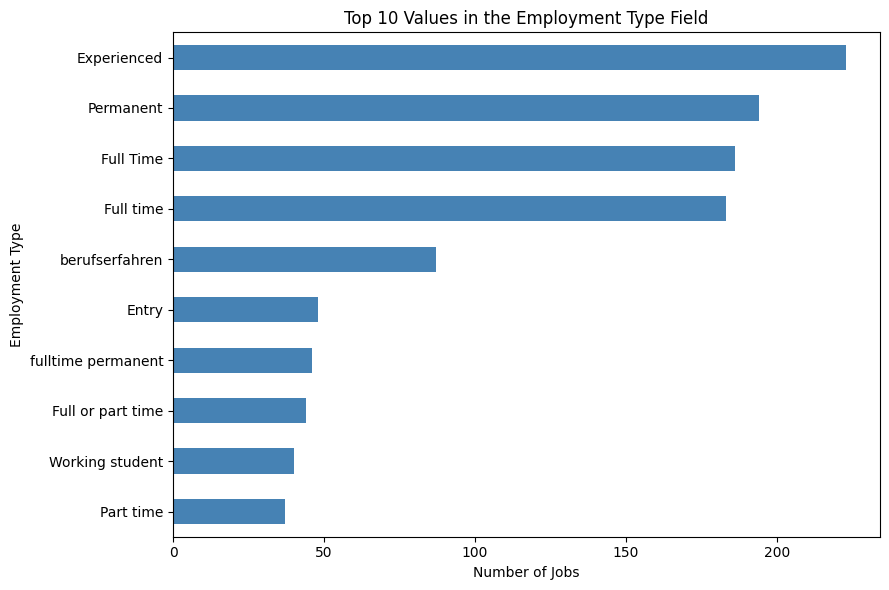

In [ ]:
#Anzahl der Stellenangebote nach Beschäftigungsart
# 不同雇佣类型的职位数量

employment_types = (
    df["employment_type"]
    .dropna()
    .str.split("|", regex=False)
    .explode()
    .str.strip()
)

# top 10
employment_counts = employment_types.value_counts().head(10)

# 横向柱状图 Balkendiagramm
plt.figure(figsize=(9, 6))

employment_counts.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Values in the Employment Type Field")
plt.xlabel("Number of Jobs")
plt.ylabel("Employment Type")
plt.tight_layout()

plt.savefig("top_10_employment_types.png", dpi=300)
plt.show()

location
Berlin                247
Munich                160
Hamburg                74
Cologne                32
Stuttgart              24
Frankfurt am Main      14
München                14
Karlsruhe              13
Mainz                  12
Berlin-Lichtenberg     12
Name: count, dtype: int64


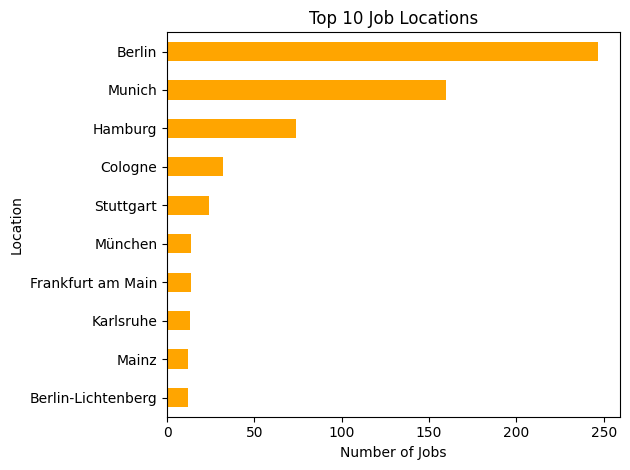

In [ ]:
#Top 10 Job Locations
city_counts = (
    df["location"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

print(city_counts)

city_counts.sort_values().plot(
    kind="barh",
    color="orange"
)

plt.title("Top 10 Job Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.tight_layout()
plt.savefig(
    "top_10_locations.png",
    dpi=300
)
plt.show()

company
Init Ag                   50
Trusteq Gmbh              15
Sunday Natural            13
Rohlik                    12
Schulze Marketing GmbH    12
Stackfuel                  9
Vogel                      8
Maibornwolff               7
Ramp106 Gmbh               7
Quantum-Systems GmbH       6
Name: count, dtype: int64


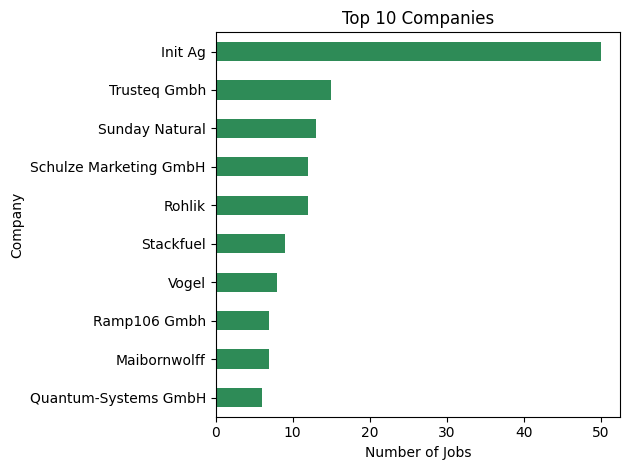

In [ ]:
#Top 10 Companies
company_counts = (
    df["company"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

print(company_counts)

company_counts.sort_values().plot(
    kind="barh",
    color="seagreen"
)

plt.title("Top 10 Companies")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig(
    "top_10_companies.png",
    dpi=300
)
plt.show()

remote_status
Not Remote    794
Remote         72
Unknown         9
Name: count, dtype: int64


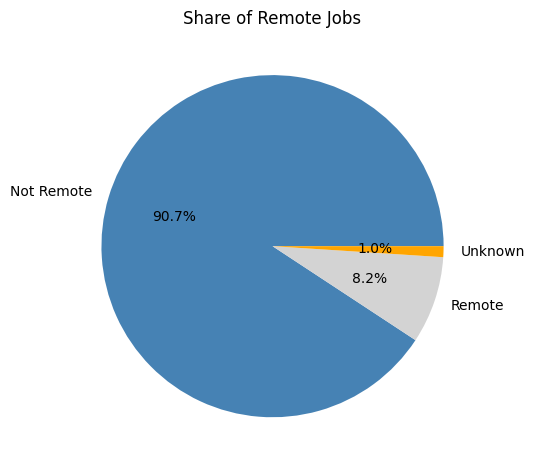

In [ ]:
#Share of Remote Jobs
def get_remote_status(tags):
    if pd.isna(tags):
        return "Unknown"

    if "remote" in tags.lower():
        return "Remote"

    return "Not Remote"


df["remote_status"] = df["tags"].apply(
    get_remote_status
)

remote_counts = df["remote_status"].value_counts()

print(remote_counts)

remote_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["steelblue", "lightgray", "orange"]
)

plt.title("Share of Remote Jobs")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    "remote_jobs.png",
    dpi=300
)
plt.show()

tags
Remote                         70
Engineering                    55
Software Development           39
Consulting                     38
Sales                          36
IT                             34
Finance                        30
Marketing                      26
Public Sector                  25
AI                             25
Marketing and Communication    23
KI                             20
Operations                     18
high school or equivalent      18
Scrum                          17
Name: count, dtype: int64


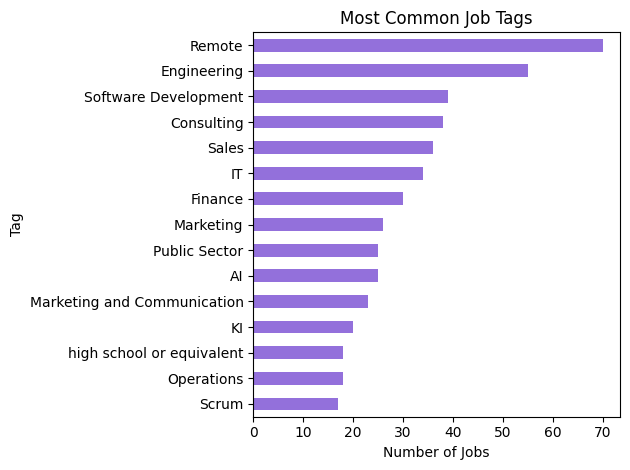

In [108]:
#最常见的职位标签
all_tags = (
    df["tags"]
    .dropna()
    .str.split(r"\|")
    .explode()
    .str.strip()
)

tag_counts = all_tags.value_counts().head(15)

print(tag_counts)

tag_counts.sort_values().plot(
    kind="barh",
    color="mediumpurple"
)

plt.title("Most Common Job Tags")
plt.xlabel("Number of Jobs")
plt.ylabel("Tag")
plt.tight_layout()
plt.savefig(
    "common_job_tags.png",
    dpi=300
)
plt.show()

Git                    415
Excel                  197
Python                 124
SQL                     90
Java                    61
JavaScript              27
Machine Learning        24
NLP                      3
Computer Linguistik      0
dtype: int64


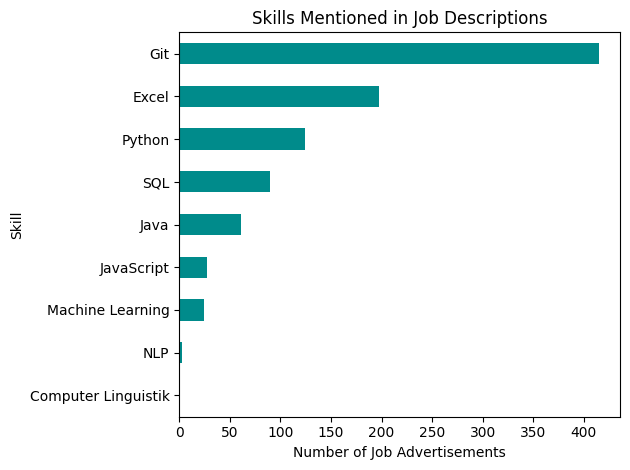

In [119]:
#常见技能关键词
skills = [
    "Python",
    "SQL",
    "Java",
    "JavaScript",
    "Excel",
    "Git",
    "Machine Learning",
    "NLP",
    "Computer Linguistik"
]

description_text = (
    df["description"]
    .fillna("")
    .str.lower()
)

skill_counts = {}

for skill in skills:
    count = description_text.str.contains(
        skill.lower(),
        regex=False
    ).sum()

    skill_counts[skill] = count

skill_counts = pd.Series(
    skill_counts
).sort_values(ascending=False)

print(skill_counts)

skill_counts.sort_values().plot(
    kind="barh",
    color="darkcyan"
)

plt.title("Skills Mentioned in Job Descriptions")
plt.xlabel("Number of Job Advertisements")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig(
    "common_skills.png",
    dpi=300
)
plt.show()

job_group
Regular Job            520
Other/Unknown          246
Internship/Training    109
Name: count, dtype: int64


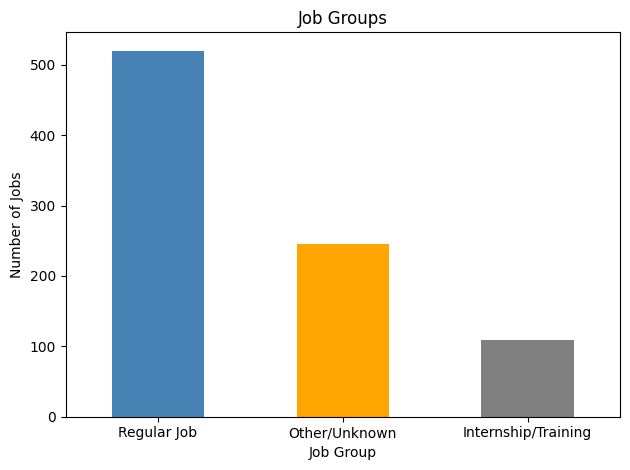

In [111]:
#区分实习/培训岗位和正式岗位
def classify_job(row):
    title = str(row["title"]).lower()
    job_type = str(row["employment_type"]).lower()

    text = title + " " + job_type

    training_words = [
        "internship",
        "praktikum",
        "praktikant",
        "werkstudent",
        "apprenticeship",
        "ausbildung"
    ]

    regular_words = [
        "full-time",
        "full time",
        "part-time",
        "part time",
        "vollzeit",
        "teilzeit",
        "permanent",
        "festanstellung",
        "berufseinstieg"
    ]

    for word in training_words:
        if word in text:
            return "Internship/Training"

    for word in regular_words:
        if word in text:
            return "Regular Job"

    return "Other/Unknown"


df["job_group"] = df.apply(
    classify_job,
    axis=1
)

group_counts = df["job_group"].value_counts()

print(group_counts)

group_counts.plot(
    kind="bar",
    color=["steelblue", "orange", "gray"]
)

plt.title("Job Groups")
plt.xlabel("Job Group")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "job_groups.png",
    dpi=300
)
plt.show()